# **MÁSTER BASKET DATA ANALYTICS - TRABAJO FINAL ASIGNATURA (TFA)**

---

## BLOQUE ESPECÍFICO: Análisis de Datos
## ASIGNATURA: **Machine Learning I**
## PROFESOR: Jaime Mallo Antelo

---

## ALUMNO: **Pablo Gómez Villamayor**
## CURSO: 2025-2026

---

## **TEMA**: Análisis-prevención de **lesiones** con datos **NBA**


---
---
---
---
---



## **COMENTARIOS GENERALES SOBRE LA ENTREGA**

He buscado realizar un **trabajo lo más completo posible**, en ambas tareas. De este modo, se ha tratado de cumplir todas las "*consideraciones*" o criterios de evaluación solicitados: Exploración de Datos, preprocesado, justificación de decisiones tomadas/modelos utilizados, etc. En todo momento, hemos buscado que el **código** sea **limpio, completo y mantenible**.

En favor de la completitud del código y de los ejercicios, se han utilizado diferentes algoritmos de Machine Learning en cada apartado. Es decir, no nos hemos limitado a generar un único modelo, sino que hemos intentado aplicar varios diferentes, y realizar un ajuste de hiperparámetros, para mejorar el desempeño de los mismos. 

Por otro lado, como se solicitaba de manera "*imprescindible*", el código ha sido debidamente comentado y las fuentes de información utilizadas han sido citadas al final del presente Notebook. 

En particular, en relación a cada tarea:

- **Tarea 1**: Se han implementado dos técnicas de clustering diferentes ('Kmeans' y 'Clustering jerárquico'), comparando el resultado. Una vez ejecutadas, se asignó una etiqueta coherente a cada grupo. 

- **Tarea 2**: Se han utilizado dos modelos diferentes, en concreto: árboles de decisión y redes neuronales. Se ha comparado el rendimiento de ambos modelos. Se ha tenido en cuenta el posible desbalanceo de clases. Por último, se han guardado/exportado los modelos, para poder ejecutarlos sin necesidad de repetir el proceso de entrenamiento.

---

## **FORMATO DEL NOTEBOOK** 

Vamos a dividir el código en varios apartados, de forma que se pueda identificar de forma clara el proceso seguido en el ejercicio. De esta forma, el presente notebook seguirá una estructura similar a la de los ejemplos propuestos en clase: Importación de librerías, carga, exploración y limpieza de datos, implementación de algoritmos de clustering, etc.

---
---
---
---
---


# **TAREA 2 - CLASIFICACIÓN**

## **ENUNCIADO** 

##### " Genera un modelo que permita determinar el riesgo o probabilidad de lesión de un jugador en base a la información proporcionada. Es necesario realizar un trabajo feature engineering** para extraer todo el potencial del dataset. 
 
##### **Feature engineering es el proceso de crear, transformar o seleccionar variables (features) a partir de los datos originales para mejorar el rendimiento de un modelo. "


---
---
---

### **1. LIBRERÍAS**

En primer lugar, cargamos las librerías que se van a utilizar en el notebook.


In [353]:
# LIBRERÍAS GENERALES


#Pandas: Dataset.
import pandas as pd

#Numpy: Matemáticas.
import numpy as np

#Matplotlib: Visualización.
import matplotlib.pyplot as plt
from matplotlib import pyplot

#Seaborn: Visualización.
#import seaborn as sns

In [354]:
# LIBRERÍAS ÁRBOLES DE DECISIÓN

#Sklearn:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix


In [355]:
# LIBRERÍAS REDES NEURONALES

#Sklearn: 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

#Keras:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import metrics
import keras_tuner as kt

#Tensorflow:
import tensorflow as tf

### **2. LECTURA DE DATOS**

A continuación, cargamos el dataset  “DatasetInjuriesByGame.csv” en nuestro notebook. Nótese que el separador utilizado es la coma (",") y la primera fila del dataset corresponde a la cabecera.

In [356]:
df = pd.read_csv('DatasetInjuriesByGame.csv', sep=',', header=0)

### **3. EXPLORACIÓN DE DATOS**

Exploramos los datos disponibles: el volumen de los mismos, tipos de variables, posible existencia de valores nulos, etc.

In [357]:
df

,PLAYER_NAME,TEAM_NAME,SEASON,SEASON_YEAR,GAME_DATE,MATCHUP,MIN,AGE,OFFRTG,DEFRTG,USG_PCT,PACE,PIE,NEXT_GAME_DATE,CLEAN_REASON,DAYS_OFF,DAYS_TO_COURT
0,Aaron Gordon,Denver Nuggets,2021-22,2022,2021-10-20,DEN @ PHX,29,26,117.3,111.1,19.4,99.00,9.6,2021-10-22,No Injury,0.0,0
1,Aaron Gordon,Denver Nuggets,2021-22,2022,2021-10-22,DEN vs. SAS,30,26,117.3,111.1,19.4,99.00,9.6,2021-10-25,No Injury,0.0,0
2,Aaron Gordon,Denver Nuggets,2021-22,2022,2021-10-25,DEN vs. CLE,28,26,117.3,111.1,19.4,99.00,9.6,2021-10-26,No Injury,0.0,0
3,Aaron Gordon,Denver Nuggets,2021-22,2022,2021-10-26,DEN @ UTA,34,26,117.3,111.1,19.4,99.00,9.6,2021-10-29,No Injury,0.0,0
4,Aaron Gordon,Denver Nuggets,2021-22,2022,2021-10-29,DEN vs. DAL,24,26,117.3,111.1,19.4,99.00,9.6,2021-10-30,No Injury,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13935,Zeke Nnaji,Denver Nuggets,2024-25,2025,2025-03-28,DEN vs. UTA,17,24,107.3,108.9,11.9,102.16,6.3,2025-04-01,No Injury,0.0,0
13936,Zeke Nnaji,Denver Nuggets,2024-25,2025,2025-04-01,DEN vs. MIN,11,24,107.3,108.9,11.9,102.16,6.3,2025-04-02,No Injury,0.0,0
13937,Zeke Nnaji,Denver Nuggets,2024-25,2025,2025-04-02,DEN vs. SAS,23,24,107.3,108.9,11.9,102.16,6.3,2025-04-04,No Injury,0.0,0
13938,Zeke Nnaji,Denver Nuggets,2024-25,2025,2025-04-04,DEN @ GSW,7,24,107.3,108.9,11.9,102.16,6.3,2025-04-13,No Injury,0.0,0


In [358]:
df.shape

(13940, 17)

Vemos que el dataset contiene 13940 filas y 17 columnas. 

Para refrescar información, incluimos en el notebook el resumen de las variables del enunciado del problema:

"

• PLAYER_NAME: Nombre del jugador que participó en el partido. 

•  TEAM_NAME: Equipo NBA al que pertenece el jugador en ese partido. 

•  SEASON: Temporada NBA en formato yyyy-yy (por ejemplo, 2023-24). 

•  SEASON_YEAR: Año final de la temporada NBA (por ejemplo, 2024 para la temporada 2023-24). 
•  GAME_DATE: Fecha en la que se disputó el partido. 

•  MATCHUP: Enfrentamiento del partido indicando equipos y localía (ej. BOS vs LAL o BOS @ LAL). 

•  MIN: Minutos jugados por el jugador en ese partido. 

•  AGE: Edad del jugador en el momento del partido. 

•  OFFRTG: Offensive Rating, puntos generados por el equipo por cada 100 posesiones cuando el 
jugador está en pista. 

•  DEFRTG: Defensive Rating, puntos permitidos por el equipo por cada 100 posesiones cuando el 
jugador está en pista. 

•  USG_PCT: Usage Percentage, porcentaje de posesiones ofensivas del equipo finalizadas por el 
jugador mientras está en cancha. 

•  PACE: Ritmo de juego estimado del equipo (posesiones por partido) cuando el jugador está en 
pista. 

•  PIE: Player Impact Estimate, métrica que estima el impacto global del jugador en el partido. 

•  NEXT_GAME_DATE: Fecha del siguiente partido del jugador después del registrado.  
 
•  CLEAN_REASON: Motivo limpio/normalizado de ausencia o lesión asociada al periodo analizado. 

•  DAYS_OFF: Número de días, en primera instancia, que el jugador estará afectado por la lesión. 

•  DAYS_TO_COURT: Número de días que el jugador tarda en volver a las pistas después de su lesión. 
Representa el tiempo que ha tardado en volver a la pista por la lesión mencionada u otras lesiones 
asociadas durante el proceso de recuperación, recaídas o durante el proceso de readaptación. 

"



In [359]:
#Veamos información de las variables, su tipo etc.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13940 entries, 0 to 13939
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PLAYER_NAME     13940 non-null  str    
 1   TEAM_NAME       13940 non-null  str    
 2   SEASON          13940 non-null  str    
 3   SEASON_YEAR     13940 non-null  int64  
 4   GAME_DATE       13940 non-null  str    
 5   MATCHUP         13940 non-null  str    
 6   MIN             13940 non-null  int64  
 7   AGE             13940 non-null  int64  
 8   OFFRTG          13940 non-null  float64
 9   DEFRTG          13940 non-null  float64
 10  USG_PCT         13940 non-null  float64
 11  PACE            13940 non-null  float64
 12  PIE             13940 non-null  float64
 13  NEXT_GAME_DATE  13745 non-null  str    
 14  CLEAN_REASON    13940 non-null  str    
 15  DAYS_OFF        13940 non-null  float64
 16  DAYS_TO_COURT   13940 non-null  int64  
dtypes: float64(6), int64(4), str(7)
memory usa

Transformamos la variable "GAME_DATE" a tipo fecha

In [360]:
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'], errors='coerce')

Sigamos con la exploración brevemente.

In [361]:
df.describe()

,SEASON_YEAR,GAME_DATE,MIN,AGE,OFFRTG,DEFRTG,USG_PCT,PACE,PIE,DAYS_OFF,DAYS_TO_COURT
count,13940.000000,13940,13940.000000,13940.000000,13940.000000,13940.000000,13940.000000,13940.000000,13940.000000,13940.000000,13940.000000
mean,2023.493472,2023-07-14 22:01:43.299856,22.466786,27.721664,112.436270,110.290280,17.912783,100.687665,9.589943,0.399498,0.521306
min,2022.000000,2021-10-19 00:00:00,0.000000,19.000000,33.300000,40.500000,0.000000,88.670000,-18.800000,0.000000,0.000000
25%,2023.000000,2022-10-18 00:00:00,14.000000,24.000000,109.300000,108.300000,13.400000,99.190000,7.500000,0.000000,0.000000
50%,2023.000000,2023-04-07 00:00:00,24.000000,27.000000,113.200000,110.700000,16.400000,100.360000,9.400000,0.000000,0.000000
75%,2024.000000,2024-04-14 00:00:00,32.000000,31.000000,117.100000,112.700000,20.600000,101.990000,11.200000,0.000000,0.000000
max,2025.000000,2025-04-13 00:00:00,53.000000,41.000000,214.300000,200.000000,40.000000,130.810000,37.600000,116.000000,625.000000
std,1.115936,NaN,11.178096,4.687218,7.492491,4.548481,5.841513,2.405281,3.676347,3.684936,10.122610


Veamos rápidamente como se distribuyen los datos.

array([[<Axes: title={'center': 'SEASON_YEAR'}>,
        <Axes: title={'center': 'GAME_DATE'}>,
        <Axes: title={'center': 'MIN'}>],
       [<Axes: title={'center': 'AGE'}>,
        <Axes: title={'center': 'OFFRTG'}>,
        <Axes: title={'center': 'DEFRTG'}>],
       [<Axes: title={'center': 'USG_PCT'}>,
        <Axes: title={'center': 'PACE'}>,
        <Axes: title={'center': 'PIE'}>],
       [<Axes: title={'center': 'DAYS_OFF'}>,
        <Axes: title={'center': 'DAYS_TO_COURT'}>, <Axes: >]],
      dtype=object)

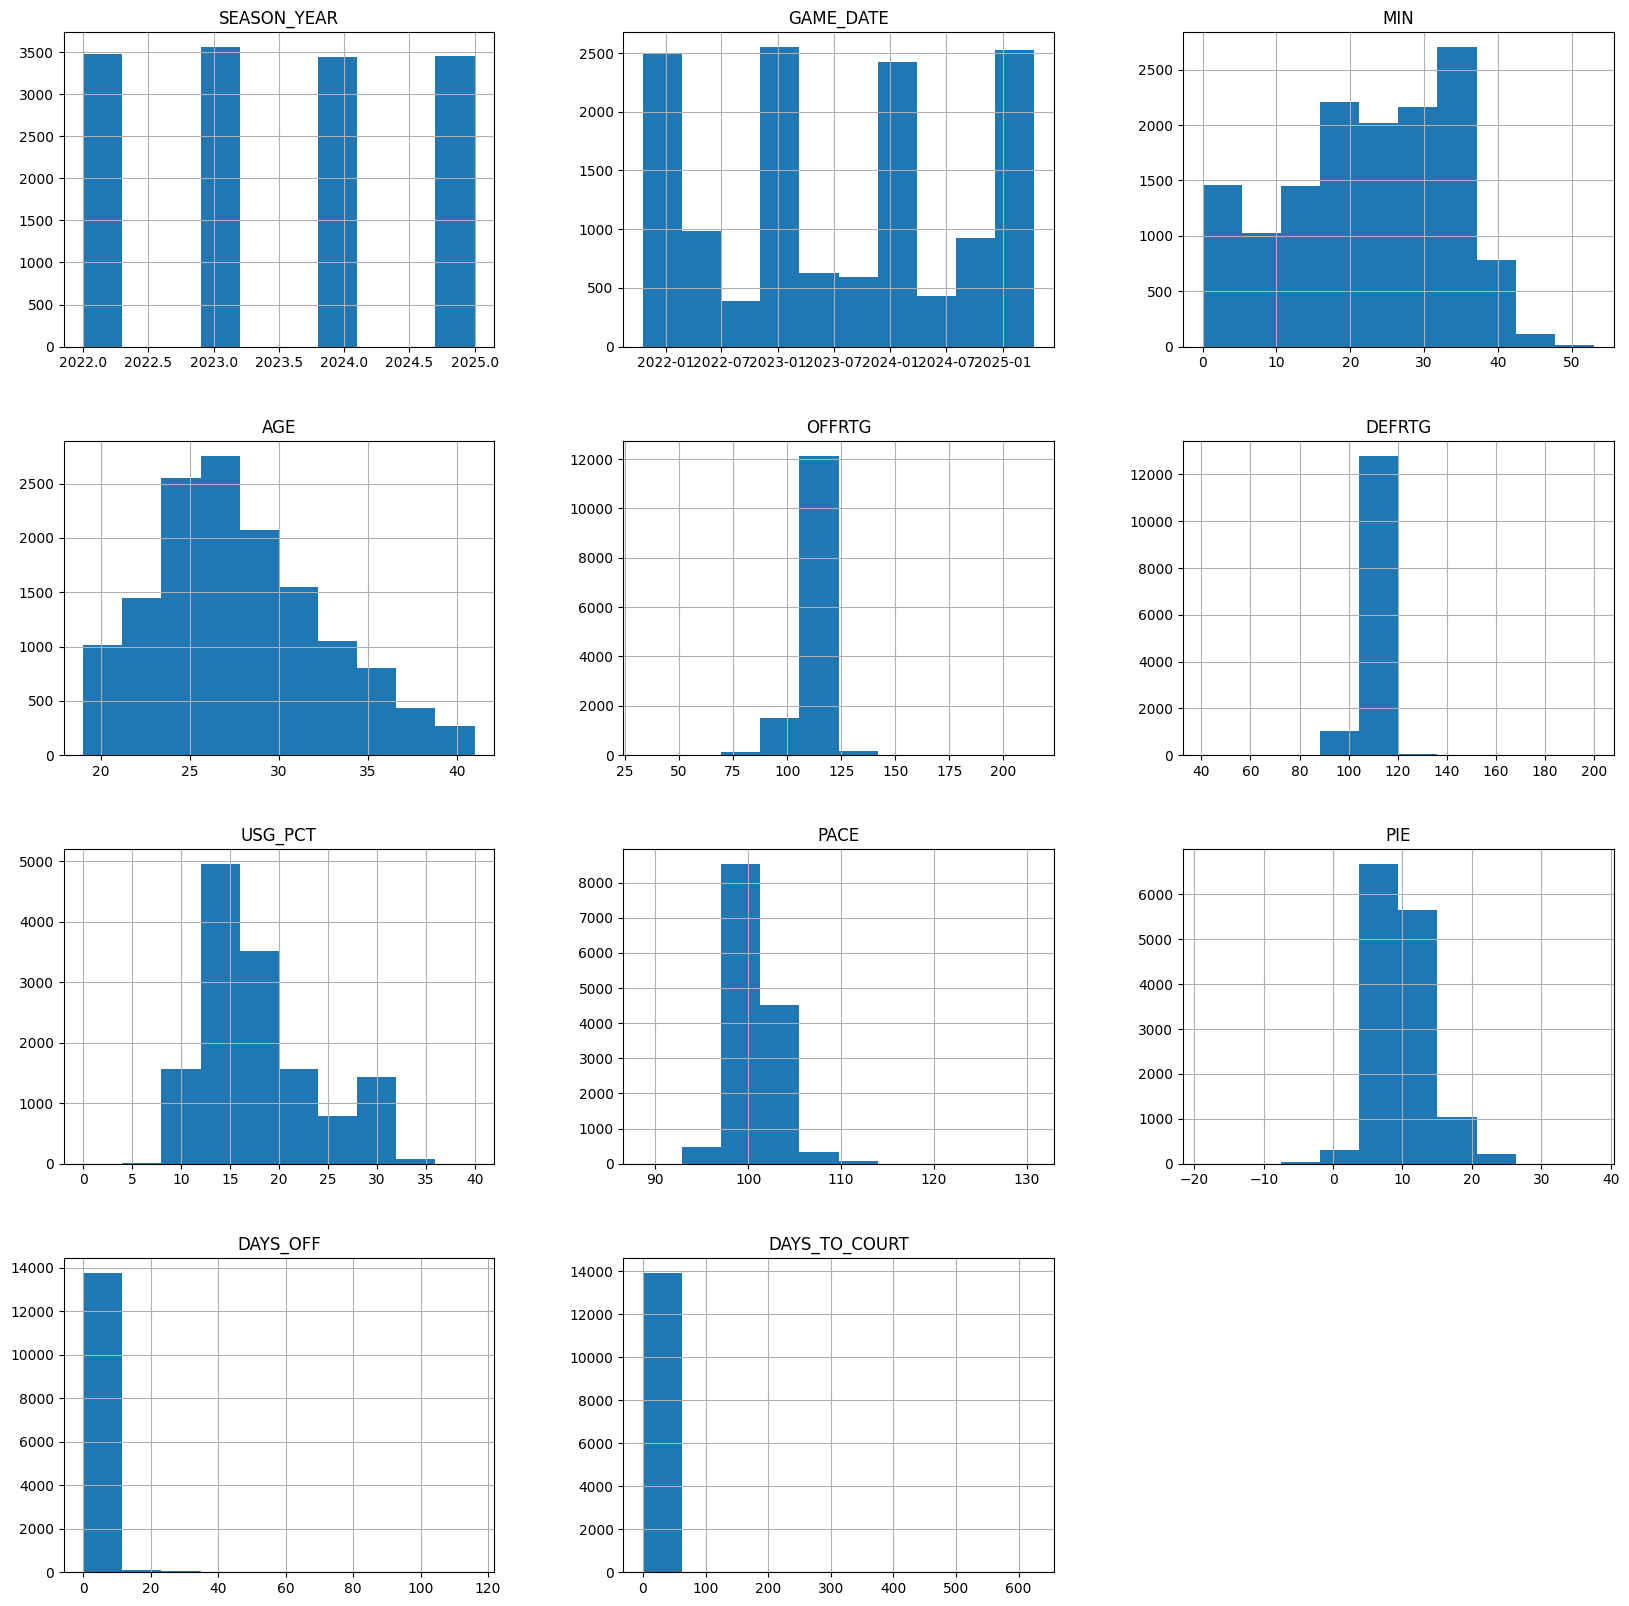

In [362]:
df.hist(figsize=(20,20))

#### **3.1. ANÁLISIS DE VALORES NULOS**

Parece que solo hay valores nulos en la columna "NEXT_GAME_DATE". Antes de continuar, nos cercioramos de ello. 

Vamos a realizar un tratamiento adecuado, como vimos en clase.

In [363]:
df.isnull().sum()

PLAYER_NAME         0
TEAM_NAME           0
SEASON              0
SEASON_YEAR         0
GAME_DATE           0
MATCHUP             0
MIN                 0
AGE                 0
OFFRTG              0
DEFRTG              0
USG_PCT             0
PACE                0
PIE                 0
NEXT_GAME_DATE    195
CLEAN_REASON        0
DAYS_OFF            0
DAYS_TO_COURT       0
dtype: int64

Vamos a analizar estos nulos. No parece que sea un problema de que falten datos. Diría que lo que ocurre es que tenemos datos de 195 jugadores-temporada diferentes, y que en el último registro de cada uno (último partido que juegue ese jugador en esa temporada), "NEXT_GAME_DATE" es nulo porque no hay próximo partido como tal.

Veámoslo.

In [364]:
df_nulos = df[df['NEXT_GAME_DATE'].isna()]
df_nulos

,PLAYER_NAME,TEAM_NAME,SEASON,SEASON_YEAR,GAME_DATE,MATCHUP,MIN,AGE,OFFRTG,DEFRTG,USG_PCT,PACE,PIE,NEXT_GAME_DATE,CLEAN_REASON,DAYS_OFF,DAYS_TO_COURT
266,Aaron Gordon,Denver Nuggets,2024-25,2025,2025-04-13,DEN @ HOU,26,29,122.5,113.0,18.6,101.64,10.4,NaN,No Injury,0.0,0
318,Aaron Nesmith,Boston Celtics,2021-22,2022,2022-04-10,BOS @ MEM,16,22,107.3,104.3,16.4,100.58,4.8,NaN,No Injury,0.0,0
575,Al Horford,Boston Celtics,2024-25,2025,2025-04-11,BOS vs. CHA,28,39,119.6,108.1,13.6,97.75,9.1,NaN,No Injury,0.0,0
579,Alex Fudge,Los Angeles Lakers,2023-24,2024,2023-11-30,LAL @ OKC,4,21,60.6,137.9,21.1,102.86,-4.7,NaN,No Injury,0.0,0
589,Alex Len,Los Angeles Lakers,2024-25,2025,2025-04-13,LAL @ POR,14,32,106.0,126.1,11.7,99.84,2.2,NaN,No Injury,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13604,Wenyen Gabriel,Los Angeles Lakers,2022-23,2023,2023-04-09,LAL vs. UTA,16,26,111.2,111.4,13.5,103.95,8.2,NaN,No Injury,0.0,0
13675,Will Barton,Denver Nuggets,2021-22,2022,2022-04-07,DEN vs. MEM,29,31,112.5,110.4,20.5,99.34,9.5,NaN,No Injury,0.0,0
13728,Xavier Tillman,Boston Celtics,2024-25,2025,2025-04-09,BOS @ ORL,7,26,106.6,108.9,12.5,97.60,2.2,NaN,No Injury,0.0,0
13730,Yuri Collins,Golden State Warriors,2024-25,2025,2025-02-25,GSW vs. CHA,10,24,94.4,111.4,6.8,104.54,4.8,NaN,No Injury,0.0,0


In [365]:
df_nulos_ordenado = df_nulos.sort_values(
    by=['SEASON_YEAR', 'TEAM_NAME', 'GAME_DATE']
)

df_nulos_ordenado

,PLAYER_NAME,TEAM_NAME,SEASON,SEASON_YEAR,GAME_DATE,MATCHUP,MIN,AGE,OFFRTG,DEFRTG,USG_PCT,PACE,PIE,NEXT_GAME_DATE,CLEAN_REASON,DAYS_OFF,DAYS_TO_COURT
2161,CJ Miles,Boston Celtics,2021-22,2022,2021-12-22,BOS vs. CLE,2,35,80.0,180.0,0.0,123.08,-9.1,NaN,No Injury,0.0,0
6570,Joe Johnson,Boston Celtics,2021-22,2022,2021-12-22,BOS vs. CLE,2,41,80.0,180.0,20.0,123.08,18.2,NaN,No Injury,0.0,0
5197,Jabari Parker,Boston Celtics,2021-22,2022,2022-01-02,BOS vs. ORL,7,27,103.9,104.7,19.1,99.67,11.7,NaN,No Injury,0.0,0
7372,Juancho Hernangomez,Boston Celtics,2021-22,2022,2022-01-08,BOS vs. NYK,2,26,98.5,117.4,15.5,100.69,2.5,NaN,No Injury,0.0,0
2043,Bruno Fernando,Boston Celtics,2021-22,2022,2022-02-08,BOS @ BKN,5,23,91.9,117.2,13.5,110.84,7.4,NaN,No Injury,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3056,Dalton Knecht,Los Angeles Lakers,2024-25,2025,2025-04-13,LAL @ POR,37,24,112.2,114.9,18.1,98.26,8.7,NaN,No Injury,0.0,0
6857,Jordan Goodwin,Los Angeles Lakers,2024-25,2025,2025-04-13,LAL @ POR,30,26,111.2,112.4,13.4,99.53,8.0,NaN,No Injury,0.0,0
9316,Markieff Morris,Los Angeles Lakers,2024-25,2025,2025-04-13,LAL @ POR,33,35,108.3,115.5,19.0,97.73,5.2,NaN,No Injury,0.0,0
12364,Shake Milton,Los Angeles Lakers,2024-25,2025,2025-04-13,LAL @ POR,43,28,106.5,114.0,15.6,98.60,7.8,NaN,No Injury,0.0,0


Efectivamente, ocurre lo que habíamos anticipado. 

Veamos la fecha últimos partidos de temporada regular de cada año. Vemos que todos corresponden a un 'GAME_DATE' de abril, cuando finaliza la temporada regular NBA.

In [366]:
df.groupby('SEASON_YEAR')['GAME_DATE'].max()

SEASON_YEAR
2022   2022-04-10
2023   2023-04-09
2024   2024-04-14
2025   2025-04-13
Name: GAME_DATE, dtype: datetime64[us]

Si ordenamos los nulos por fecha, vemos que la última es el "2025-04-13", que es exactamente el último partido de temporada regular. Es decir, coincide con la fecha "máxima" (más tardía) de "SEASON_YEAR" 2025

In [367]:
df_nulos['GAME_DATE'].sort_values().tail(5)

10244   2025-04-13
10613   2025-04-13
11193   2025-04-13
11432   2025-04-13
13939   2025-04-13
Name: GAME_DATE, dtype: datetime64[us]

Veamos como se distribuyen los nulos en cada uno de los meses del año (Abril es el mes 4)

In [368]:
df_nulos['GAME_DATE'].dt.month.value_counts()

GAME_DATE
4     132
1      19
2      18
12     12
3       8
11      5
10      1
Name: count, dtype: int64

Vemos que la mayoría de nulos (132 de 195) son en Abril, lo que corresponde al último partido de temporada regular. El resto de nulos corresponden a jugadores cortados por los equipos durante la temporada regular. Se observa como se van cortando más jugadores a medida que avanzan los meses: 

- Octubre (mes 10) -> 1 nulo.
- Noviembre (mes 11) -> 5 nulos.
- Diciembre (mes 12) -> 12 nulos.
- Enero (mes 1) -> 19 nulos.
- Febrero (mes 2) -> 18 nulos.





Como última comprobación, veamos que los nulos son efectivamente el último partido de ese jugador en esa temporada

In [369]:
df_sorted = df.sort_values(by=['PLAYER_NAME', 'GAME_DATE'])

df_sorted['NEXT_GAME_REAL'] = df_sorted.groupby('PLAYER_NAME')['GAME_DATE'].shift(-1)

#La variable 'NEXT_GAME_REAL' sirve para ver la fecha del siguiente (shift -1) partido de ese jugador.
#Si estamos en lo cierto, 'NEXT_GAME_REAL' debería tener valor nulo siempre que 'NEXT_GAME_DATE' lo sea

df_sorted[df_sorted['NEXT_GAME_DATE'].isna()]

,PLAYER_NAME,TEAM_NAME,SEASON,SEASON_YEAR,GAME_DATE,MATCHUP,MIN,AGE,OFFRTG,DEFRTG,USG_PCT,PACE,PIE,NEXT_GAME_DATE,CLEAN_REASON,DAYS_OFF,DAYS_TO_COURT,NEXT_GAME_REAL
266,Aaron Gordon,Denver Nuggets,2024-25,2025,2025-04-13,DEN @ HOU,26,29,122.5,113.0,18.6,101.64,10.4,NaN,No Injury,0.0,0,NaT
318,Aaron Nesmith,Boston Celtics,2021-22,2022,2022-04-10,BOS @ MEM,16,22,107.3,104.3,16.4,100.58,4.8,NaN,No Injury,0.0,0,NaT
575,Al Horford,Boston Celtics,2024-25,2025,2025-04-11,BOS vs. CHA,28,39,119.6,108.1,13.6,97.75,9.1,NaN,No Injury,0.0,0,NaT
579,Alex Fudge,Los Angeles Lakers,2023-24,2024,2023-11-30,LAL @ OKC,4,21,60.6,137.9,21.1,102.86,-4.7,NaN,No Injury,0.0,0,NaT
589,Alex Len,Los Angeles Lakers,2024-25,2025,2025-04-13,LAL @ POR,14,32,106.0,126.1,11.7,99.84,2.2,NaN,No Injury,0.0,0,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13604,Wenyen Gabriel,Los Angeles Lakers,2022-23,2023,2023-04-09,LAL vs. UTA,16,26,111.2,111.4,13.5,103.95,8.2,NaN,No Injury,0.0,0,NaT
13675,Will Barton,Denver Nuggets,2021-22,2022,2022-04-07,DEN vs. MEM,29,31,112.5,110.4,20.5,99.34,9.5,NaN,No Injury,0.0,0,NaT
13728,Xavier Tillman,Boston Celtics,2024-25,2025,2025-04-09,BOS @ ORL,7,26,106.6,108.9,12.5,97.60,2.2,NaN,No Injury,0.0,0,NaT
13730,Yuri Collins,Golden State Warriors,2024-25,2025,2025-02-25,GSW vs. CHA,10,24,94.4,111.4,6.8,104.54,4.8,NaN,No Injury,0.0,0,NaT


In [370]:
df_sorted[ df_sorted['NEXT_GAME_DATE'].isna() & df_sorted['NEXT_GAME_REAL'].notna() ]

,PLAYER_NAME,TEAM_NAME,SEASON,SEASON_YEAR,GAME_DATE,MATCHUP,MIN,AGE,OFFRTG,DEFRTG,USG_PCT,PACE,PIE,NEXT_GAME_DATE,CLEAN_REASON,DAYS_OFF,DAYS_TO_COURT,NEXT_GAME_REAL


Efectivamente, estábamos en lo cierto. De este modo, no es un problema de que existan datos faltantes.

Esa variable no la vamos a utilizar tal cual, así que no hay problema con estos nulos. Veremos posteriormente cómo vamos a tratar otros posibles nulos que se generen.

### **4. PLANTEAMIENTO DEL PROBLEMA**


Estamos ante un problema de clasificación binaria. Nuestro objetivo es construir un modelo que estime el riesgo de lesión. 

Para ello, vamos a construir nuestra variable objetivo, a partir de la variable "DAYS_OFF".

Vamos a llamar "injury" a dicha variable. Así:

- "DAYS_OFF" == 0 -> NO LESIÓN -> "injury" = 0. 

- "DAYS_OFF" > 0 -> SÍ LESIÓN -> "injury" = 1.

De este modo:

In [371]:
df['injury'] = (df['DAYS_OFF'] > 0).astype(int)

### **5. FEATURE ENGINEERING**

A continuación, pasamos a la parte fundamental de la tarea. 

Vamos a transformar algunas variables y a crear otras nuevas a partir de los datos existentes. Además, realizaremos un proceso de selección (feature) de las variables que puedan resultar relevantes para el modelo, pues algunas no aportaran valor o serán redundantes.

#### **5.1. CREACIÓN DE VARIABLES TEMPORALES**

Recordemos que ya habíamos transformado 'GAME_DATE' a tipo datetime. 

Ahora, ordenamos el dataset por jugador y fecha.

Creamos una nueva variable "days_between_games", que indica el número de días entre un partido y el siguiente. Este será uno de los indicadores de fatiga acumulada (posible indicador de lesión).

In [372]:
#df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

df = df.sort_values(['PLAYER_NAME', 'GAME_DATE'])

df['days_between_games'] = df.groupby('PLAYER_NAME')['GAME_DATE'].diff().dt.days

Generamos una nueva variable booleana "back_to_back", que tomará el valor 1 sí "days_between_games" es exactamente igual a 1, es decir, si se juegan partidos en días consecutivos. 

Los back to back son un claro factor asociado a un mayor riesgo de lesión. De hecho, hay jugadores con largos historiales de lesión que en muchos momentos de sus carreras evitan jugar back to backs (ejemplo: Joel Embiid).

In [373]:
df['back_to_back'] = (df['days_between_games'] == 1).astype(int)

Por último, vamos a utilizar la "idea/pista" que nos daban en el enunciado del ejercicio para tratar con series temporales: Utilizar funciones de ventana.

In [374]:
df['rolling_min_3'] = df.groupby('PLAYER_NAME')['MIN'].rolling(3).mean().reset_index(0, drop=True)

Con "rolling(k)" en python podemos tomar una ventana de k filas consecutivas y aplicarles una operación. 

En nuestro caso, lo usamos para calcular la media de minutos del jugador en los 3 partidos anteriores (el partido en cuestión, y los dos previos). 

Guardamos el resultado en una nueva variable, 'rolling_min_3'.


Con un razonamiento similar, calculamos el usage medio en los 3 partidos anteriores. También puede darnos una idea del desgaste físico del jugador. No importa solo los minutos que un jugador juegue, sino también puede ser relevante cómo son esos minutos, que responsabilidad tinene, cuántos tiros toma, etc.

In [375]:
df['rolling_usg_3'] = df.groupby('PLAYER_NAME')['USG_PCT'].rolling(3).mean().reset_index(0, drop=True)

Así queda nuestro dataset, con estas nuevas variables:

In [376]:
df.columns

Index(['PLAYER_NAME', 'TEAM_NAME', 'SEASON', 'SEASON_YEAR', 'GAME_DATE',
       'MATCHUP', 'MIN', 'AGE', 'OFFRTG', 'DEFRTG', 'USG_PCT', 'PACE', 'PIE',
       'NEXT_GAME_DATE', 'CLEAN_REASON', 'DAYS_OFF', 'DAYS_TO_COURT', 'injury',
       'days_between_games', 'back_to_back', 'rolling_min_3', 'rolling_usg_3'],
      dtype='str')

#### **5.2. TRATAMIENTO DE NULOS**

Vemos que se han generado nuevos nulos.

In [377]:
df.isnull().sum()


PLAYER_NAME             0
TEAM_NAME               0
SEASON                  0
SEASON_YEAR             0
GAME_DATE               0
MATCHUP                 0
MIN                     0
AGE                     0
OFFRTG                  0
DEFRTG                  0
USG_PCT                 0
PACE                    0
PIE                     0
NEXT_GAME_DATE        195
CLEAN_REASON            0
DAYS_OFF                0
DAYS_TO_COURT           0
injury                  0
days_between_games    195
back_to_back            0
rolling_min_3         386
rolling_usg_3         386
dtype: int64

Como ya comentamos, los de "NEXT_GAME_DATE" no son relevantes porque no vamos a usar esa variable. Los nulos de las otras tres variables sí lo son.

Podríamos completar estos nulos con algún valor (media o '0'), pero esto rompería la lógica de los datos. 

Los valores nulos las  variables temporales que hemos generado se deben a la imposibilidad de calcular diferencias o medias móviles en los primeros/últimos partidos de cada jugador. Por ello, hay 195 nulos en "days_between_games" y 386 en las otras variables (386 es apróximadamente 195 * 2).

En lugar de imputar valores artificiales, hemos decidido eliminar estas observaciones para preservar la coherencia temporal de las variables.

Nuestro dataset tiene 13k observaciones, por lo que eliminar 200-400 no va afectar a la calidad de nuestro dataset.

In [378]:
df = df.dropna(subset=[
    'days_between_games',
    'rolling_min_3',
    'rolling_usg_3'
])

In [379]:
df.isnull().sum()


PLAYER_NAME             0
TEAM_NAME               0
SEASON                  0
SEASON_YEAR             0
GAME_DATE               0
MATCHUP                 0
MIN                     0
AGE                     0
OFFRTG                  0
DEFRTG                  0
USG_PCT                 0
PACE                    0
PIE                     0
NEXT_GAME_DATE        183
CLEAN_REASON            0
DAYS_OFF                0
DAYS_TO_COURT           0
injury                  0
days_between_games      0
back_to_back            0
rolling_min_3           0
rolling_usg_3           0
dtype: int64

#### **5.3. SELECCIÓN DE VARIABLES**

Como variables de entrada de nuestro modelo vamos a utilizar:

- EDAD: 'AGE'.

- MINUTOS JUGADOS: 'MIN'.

Ambas son claramente determinante de cara a una posible lesión.

- VARIABLES DE RENDIMIENTO: 'USG_PCT', 'PACE', 'PIE','OFFRTG' Y 'DEFRTG. Estas nos dan información sobre el desempeño/desgaste del jugador en los partidos, lo cual puede ser un factor de riesgo de lesión.

- VARIABLES TEMPORALES CREADAS: 'days_between_games', 'back_to_back', 'rolling_min_3', 'rolling_usg_3'. Ya comentamos su interés anteriormente en el notebook.

In [380]:
features = ['AGE','MIN',
'USG_PCT','PACE','PIE','OFFRTG','DEFRTG',
'days_between_games', 'back_to_back','rolling_min_3','rolling_usg_3']

Con esto, finaliza el proceso previo: preprocesado de datos, limpieza, transformación, selección de variables relevantes para el problema, etc. Vamos con la implementación de los modelos.

---

### **6. ÁRBOLES DE REGRESIÓN**

Cómo vimos en clase, los árboles de decisión no requieren escalado de las variables. 

In [381]:
X = df[features]
y = df['injury']

In [382]:
X

,AGE,MIN,USG_PCT,PACE,PIE,OFFRTG,DEFRTG,days_between_games,back_to_back,rolling_min_3,rolling_usg_3
2,26,28,19.4,99.00,9.6,117.3,111.1,3.0,0,29.000000,19.4
3,26,34,19.4,99.00,9.6,117.3,111.1,1.0,1,30.666667,19.4
4,26,24,19.4,99.00,9.6,117.3,111.1,3.0,0,28.666667,19.4
5,26,31,19.4,99.00,9.6,117.3,111.1,1.0,1,29.666667,19.4
6,26,28,19.4,99.00,9.6,117.3,111.1,2.0,0,27.666667,19.4
...,...,...,...,...,...,...,...,...,...,...,...
13935,24,17,11.9,102.16,6.3,107.3,108.9,4.0,0,14.000000,11.9
13936,24,11,11.9,102.16,6.3,107.3,108.9,4.0,0,13.666667,11.9
13937,24,23,11.9,102.16,6.3,107.3,108.9,1.0,1,17.000000,11.9
13938,24,7,11.9,102.16,6.3,107.3,108.9,2.0,0,13.666667,11.9


#### **6.1. SEPARACIÓN DE TRAIN / TEST**

Pasamos directamente a separar el conjunto en train-test, con una proporción de 75%-25%.

In [383]:
seed = 13 #Como en clase, definimos la semilla para que al volver a ejecutar el notebook se obtengan los mismos resultados. Esto no es imprescindible.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=seed
)

Nótese como separamos el conjunto de test antes del ajuste de hiperparámetros para evitar sobreajuste.

#### **6.2. AJUSTE DE HIPERPARÁMETROS: GRID SEARCH**

Seguimos el proceso visto en clase

In [384]:
param_grid = {
    'max_depth': [3, 5, 10],
    'splitter': ['best', 'random'],
    'min_samples_split': [2, 5, 10]
}

model = tree.DecisionTreeClassifier(
    random_state=seed,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    verbose=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=13)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [385]:
final_model = grid_search.best_estimator_
final_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",13
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Nos quedamos con el splitter 'random'. 

Vemos que algunos parámetros ('max_depth') se encuentran en el extremo del intervalo. Añadimos nuevos valores, y veamos el resultado.

In [386]:
param_grid_2 = {
    'max_depth': [10,30,100],
    'splitter': ['random'],
    'min_samples_split': [4,5,6]
}

model = tree.DecisionTreeClassifier(
    random_state=seed,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid_2,
    cv=5,
    verbose=True
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=13)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 30, ...], 'min_samples_split': [4, 5, ...], 'splitter': ['random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

Nos quedamos con min_samples_split '4', y realizamos la última prueba para 'max_depth'. Veamos el resultado

In [387]:
param_grid_3 = {
    'max_depth': [25,27,30,32,35],
    'splitter': ['random'],
    'min_samples_split': [4,5,6]
}

model = tree.DecisionTreeClassifier(
    random_state=seed,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid_3,
    cv=5,
    verbose=True
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=13)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [25, 27, ...], 'min_samples_split': [4, 5, ...], 'splitter': ['random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [388]:
final_model_def = grid_search.best_estimator_
final_model_def




,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",13
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Por último, veamos las mejores combinaciones y la diferencia entre errores.

In [389]:
results = pd.DataFrame(grid_search.cv_results_)
results.sort_values(by='rank_test_score', inplace=True)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,0.015365,0.001207,0.002195,0.000399,30,4,random,"{'max_depth': 30, 'min_samples_split': 4, 'spl...",0.956714,0.939990,0.958682,0.947860,0.953763,0.951402,0.006776,1
9,0.025732,0.004434,0.004985,0.000629,32,4,random,"{'max_depth': 32, 'min_samples_split': 4, 'spl...",0.956714,0.939990,0.958682,0.947860,0.953763,0.951402,0.006776,1
12,0.023934,0.005748,0.003791,0.000746,35,4,random,"{'max_depth': 35, 'min_samples_split': 4, 'spl...",0.956714,0.939990,0.958682,0.947860,0.953763,0.951402,0.006776,1
3,0.015752,0.000746,0.002997,0.001089,27,4,random,"{'max_depth': 27, 'min_samples_split': 4, 'spl...",0.956714,0.939990,0.956222,0.947860,0.953763,0.950910,0.006302,4
0,0.017553,0.001339,0.003004,0.000904,25,4,random,"{'max_depth': 25, 'min_samples_split': 4, 'spl...",0.956714,0.940482,0.952779,0.948844,0.951303,0.950025,0.005412,5
4,0.015365,0.001355,0.002981,0.000019,27,5,random,"{'max_depth': 27, 'min_samples_split': 5, 'spl...",0.951795,0.944417,0.946385,0.942450,0.948844,0.946778,0.003283,6
10,0.030518,0.000798,0.005440,0.000455,32,5,random,"{'max_depth': 32, 'min_samples_split': 5, 'spl...",0.948844,0.941466,0.946385,0.942450,0.941958,0.944220,0.002895,7
13,0.020162,0.002048,0.003782,0.000396,35,5,random,"{'max_depth': 35, 'min_samples_split': 5, 'spl...",0.948352,0.941466,0.946385,0.942450,0.941958,0.944122,0.002740,8
7,0.018735,0.003121,0.004386,0.000475,30,5,random,"{'max_depth': 30, 'min_samples_split': 5, 'spl...",0.946385,0.941466,0.946385,0.942450,0.941958,0.943728,0.002191,9
2,0.015003,0.000828,0.002640,0.000517,25,6,random,"{'max_depth': 25, 'min_samples_split': 6, 'spl...",0.945893,0.939006,0.941958,0.941958,0.947860,0.943335,0.003148,10


En este caso, nos vamos a quedar con la mejor combinación de hiperparámetros: 
{'splitter': 'random', 'max_depth': 30, 'min_samples_split': 4}

Con estos valores, realizamos el entrenamiento final del modelo. 

#### **6.3. ENTRENAMIENTO**

In [390]:
# HIPERPARÁMETROS DEL MODELO FINAL

splitter="random"         
max_depth=30   
min_samples_split=4 

# DEFINICIÓN DEL MODELO

final_model_tree = tree.DecisionTreeClassifier(splitter=splitter, max_depth=max_depth, min_samples_split=min_samples_split, class_weight='balanced',random_state=seed)

# ENTRENAMIENTO

final_model_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",13
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

#### **6.4. EVALUACIÓN**

In [391]:
y_pred_tree = final_model_tree.predict(X_test)

print(classification_report(y_test, y_pred_tree))
matriz_tree=confusion_matrix(y_test, y_pred_tree)
matriz_tree

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3321
           1       0.04      0.09      0.06        68

    accuracy                           0.94      3389
   macro avg       0.51      0.52      0.51      3389
weighted avg       0.96      0.94      0.95      3389



array([[3191,  130],
       [  62,    6]])

Los datos del test han sido:

Clase 0 (no lesión):
precision = 0.98
recall    = 0.96

Clase 1 (lesión):
precision = 0.04
recall    = 0.09

Si nos fijamos en el soporte, hay un claro desbalanceo de clases: Clase 0: 3321 vs Clase 1: 68.

El modelo solo detecta el 9% de las lesiones reales. Y, cuando predice lesión, solo acierta el 4%. 

Es decir, el rendimiento del modelo es bastante pobre. En  este contexto sabemos que es más crítico detectar lesiones (minimizar falsos negativos) que maximizar la precisión global. 

Vemos una vez más que estamos ante un problema complicado. Nuestro conocimiento experto sobre el baloncesto ya nos anticipa la dificultad de predecir lesiones. Aún así, intentaremos mejorar un poco el modelo, solucionando el desbalanceo entre las clases del conjunto de train.

In [392]:
#Se aprecia un dataset claremente desbalanceado. 
y.value_counts(normalize=True)

injury
0    0.98067
1    0.01933
Name: proportion, dtype: float64

#### **6.5. VARIABLES PRINCIPALES DEL PRIMER MODELO**

Para finalizar, se analizan las variables más relevantes en la predicción del riesgo de lesión.

<Axes: >

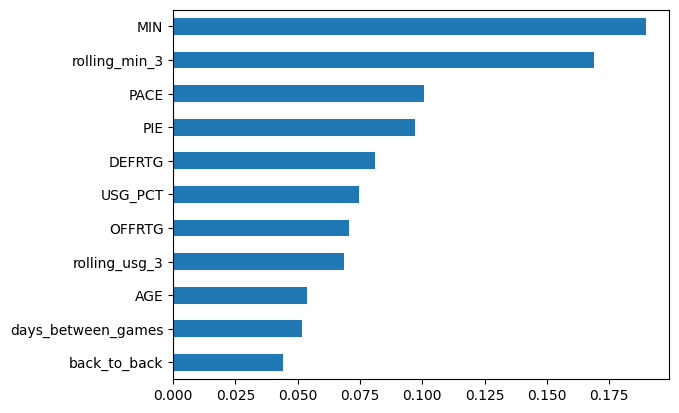

In [393]:
importances = pd.Series(final_model_tree.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')

Para finalizar, se analizan las variables más relevantes en la predicción del riesgo de lesión. Nuestro modelo de árbol ha otorgado más importancia:

-MIN

-rolling_min_3

-PACE

A la vista de los datos, nuestro modelo sugiere que la carga de minutos total (tanto en el propio partido, como en los dos partidos previos) es más relevante de cara a predecir una lesión que el porcentaje de uso o el número de días entre partido.

#### **6.6. POSIBLE MEJORA DEL MODELO: OVERSAMPLING**

Vamos a implementar una de las técnicas mencionadas en clase para tratar el desbalanceo de clases: La creación de ejemplos sintéticos de la clase minoritaria. 

En inglés, sus siglas son 'SMOTE': 'Synthetic Minority Over-sampling Technique'.

In [394]:
# LIBRERÍA NECESARIA
#pip install imbalanced-learn

In [395]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=13)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Veamos que ahora las clases están balanceadas en el nuevo conjunto de train.

In [396]:
pd.Series(y_train_res).value_counts()

injury
0    9971
1    9971
Name: count, dtype: int64

Volvemos a ajustar hiperparámetros, a partir de la última configuración.

In [397]:
grid_search.fit(X_train_res, y_train_res)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=13)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [25, 27, ...], 'min_samples_split': [4, 5, ...], 'splitter': ['random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

Nos quedamos con la mejor combinación.

In [398]:
final_model_smote = grid_search.best_estimator_
final_model_smote

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",35
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",13
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Y repetimos la evaluación:

In [399]:
y_pred_tree_smote = final_model_smote.predict(X_test)

print(classification_report(y_test, y_pred_tree_smote))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3321
           1       0.08      0.13      0.10        68

    accuracy                           0.95      3389
   macro avg       0.53      0.55      0.54      3389
weighted avg       0.96      0.95      0.96      3389



In [400]:
#Vemos que el modelo ha sido capaz de detectar más lesione que antes. 
matriz_tree_smote = confusion_matrix(y_test, y_pred_tree_smote)
matriz_tree_smote

array([[3220,  101],
       [  59,    9]])

#### **6.7. COMPARATIVA DEL MODELO: DATOS ORIGINALES VS OVERSAMPLING**

Comparemos los resultados obtenidos al generar el modelo usando oversampling (SMOTE).

Nos centramos en la clase de lesión, pues esta es la que nos interesa predecir.

| Métrica (Clase 1 - Lesión) | Modelo original | Modelo con SMOTE | Variación |
|---------------------------|---------------|------------------|-----------|
| Precision                 | 0.04          | 0.08             | ↑ Mejora |
| Recall                    | 0.09          | 0.13             | ↑ Mejora |
| F1-score                  | 0.06          | 0.10             | ↑ Mejora |

Vemos que:

- La capacidad del modelo para detectar lesiones (recall) mejora, pasando de 0.09 a 0.13.
- La precisión también aumenta.
- La métrica F1-score mejora -> Mejor equilibrio entre precisión y recall.

Aunque el accuracy global se mantiene alto (~0.95), este valor resulta poco representativo debido al fuerte desbalanceo del dataset. 

En este contexto, resulta más relevante la métrica del recall de la clase lesión, ya que el coste de no detectar una lesión (falso negativo) es mayor que el de generar una falsa alarma (falso positivo).

En conclusión, es claro que la aplicación de SMOTE mejora el rendimiento del modelo en la detección de lesiones. Sin embargo, pese a la ligera mejora, las métricas para la clase de lesión están lejos de ser perfectas. Esto nos reafirma en lo que sabíamos por nuestro conocimiento experto: 

¡¡¡PREDECIR LESIONES ES UN PROBLEMA ALTAMENTE COMPLEJO!!!

Para mejorar el rendimiento del modelo, algunas opciones a valorar serían:

- Mejorar el feature engineering: Seleccionar más variables, generar otras diferentes, etc.

- Incorporación de nuevas fuentes de datos: Aumentar el dataset con más temporadas/lesiones.

- Uso de modelos más complejos. Sabemos que los árboles de regresión no son el modelo más avanzado, y existen otros más complejos. En particular, en la siguiente sección probaremos con las redes neuronales.

#### **6.8. GUARDADO DEL MODELO**

Como se menciona en el enunciado, se valorará positivamente el guardado del modelo. Así, para guardar modelos de sklearn usamos la librería pickle.

Esto nos permite almacenar el modelo entrenado para su posterior reutilización, sin necesidad de reentrenamiento.

In [401]:
# LIBRERÍA

import pickle

# NOMBRES

filename_1 = "decision_tree_model.pkl"
filename_2 = "decision_tree_model_smote.pkl"

# GUARDAR MODELOS

pickle.dump(final_model_tree, open(filename_1, "wb"))
pickle.dump(final_model_smote, open(filename_2, "wb"))

In [ ]:
# CARGAR MODELOS

loaded_model_orig = pickle.load(open(filename_1,"rb"))
loaded_model_smote = pickle.load(open(filename_2,"rb"))


In [ ]:
# USAR MODELOS CARGADOS PARA PREDICCIÓN

y_pred_loaded_orig = loaded_model_orig.predict(X_test)
y_pred_loaded_smote = loaded_model_smote.predict(X_test)

print("\n--------------RESULTADOS MODELO ORIGINAL-------------------\n")
print(classification_report(y_test, y_pred_loaded_orig))
print("\n-------------------------------------------------------")
print("-------------------------------------------------------")
print("-------------------------------------------------------\n")
print("\n--------------RESULTADOS MODELO SMOTE-------------------\n")
print(classification_report(y_test, y_pred_loaded_smote))


--------------RESULTADOS MODELO ORIGINAL-------------------

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3321
           1       0.04      0.09      0.06        68

    accuracy                           0.94      3389
   macro avg       0.51      0.52      0.51      3389
weighted avg       0.96      0.94      0.95      3389


-------------------------------------------------------
-------------------------------------------------------
-------------------------------------------------------


--------------RESULTADOS MODELO SMOTE-------------------

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3321
           1       0.08      0.13      0.10        68

    accuracy                           0.95      3389
   macro avg       0.53      0.55      0.54      3389
weighted avg       0.96      0.95      0.96      3389



Efectivamente, vemos que los modelos se han cargado correctamente, y que obtenemos exactamente los mismos resutlados que antes.

Sin más comentarios, pasamos al bloque de redes neuronales.

### **7. REDES NEURONALES**

A modo ilustrativo presentamos un esquema de una red neuronal genérica. Posteriormente, continuamos con el ejercicio. 

Cabe mencionar que la imagen que se presenta a continuación es de elaboración propia (utilizando \LaTeX). 

Dicha imagen se encuentra disponible, en su resolución original, en mi repositorio de GitHub. Puedes acceder al mismo utilizando el siguiente enlace:

https://github.com/PabloGomezVillamayor/MBDA/tree/main/2-BLOQUE_MACHINE_LEARNING/1-Machine_Learning_I

In [404]:
#LIBRERÍA PARA INCLUIR IMÁGENES EN EL NOTEBOOK

from IPython.display import Image

Image(url="MBDA_TFA_MLI_NeuralNetworkGeneric.jpg")

---

Recordamos las variables seleccionadas para la generación del modelo.

In [405]:
df[features].info()


<class 'pandas.DataFrame'>
Index: 13554 entries, 2 to 13939
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AGE                 13554 non-null  int64  
 1   MIN                 13554 non-null  int64  
 2   USG_PCT             13554 non-null  float64
 3   PACE                13554 non-null  float64
 4   PIE                 13554 non-null  float64
 5   OFFRTG              13554 non-null  float64
 6   DEFRTG              13554 non-null  float64
 7   days_between_games  13554 non-null  float64
 8   back_to_back        13554 non-null  int64  
 9   rolling_min_3       13554 non-null  float64
 10  rolling_usg_3       13554 non-null  float64
dtypes: float64(8), int64(3)
memory usage: 1.2 MB


Todas son variables numéricas y ya hemos tratado los nulos. No consideramos ninguna variable categórica, por lo que no hay que hacer transformaciones de ellas. 

Recordamos que las redes neuronales si son sensibles a la escala de las variables. Por ello, antes de realizar generar el modelo y realizar el entrenamiento, debemos escalar las variables de entrada, como vimos en clase.

#### **7.1. ESCALADO**

In [406]:
#Ya habíamos defiido X e y. No hace falta repetirlo.
#X = df[features]
#y = df['injury']


Nótese que la variable a predecir (target, "injury") es binaria: 0 ó 1. Luego no hay que realizar escalado en la salida.

In [407]:
# ESCALAMOS

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### **7.2. DIVIDIR TRAIN/TEST**

In [408]:
#Definimos semilla -> Para la reproductibilidad del código (que al ejecutarlo genere siempre los mismos resultados).
seed=13
keras.utils.set_random_seed(seed)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.25,random_state=seed)

print("Datos de train: {d}".format(d=len(X_train)))
print("Datos de test: {d}".format(d=len(X_test)))

Datos de train: 10165
Datos de test: 3389


#### **7.3 - NO - AJUSTE HIPERPARÁMETROS -> NO FINALIZADO!**


Comencé a ejecutarlo, pero no estaba obteniendo el resultado esperado. 

Hice varias pruebas, pero no las completé porque suponían un coste computacional muy elevado (demasiado tiempo de ejecución del que no disponía). Sería interesante realizarlo de cara a mejorar el modelo de red neuronal.

En favor de la completitud del notebook, dejo el código que usé comentado, aunque su ejecución no se completó.

In [409]:
'''
param_grid = {
    'activation': ['relu', 'tanh'],   # más realista que sigmoid aquí
    'neurons_l1_min': 100,
    'neurons_l1_max': 104,
    'neurons_l2_min': 16,
    'neurons_l2_max': 20,
    'neurons_l3_min': 30,
    'neurons_l3_max': 32,
    'step': 16,
    'learning_rate': [0.001, 0.0005, 0.0001]
}

def nn_model(hp):

    model = Sequential()

    # CAPA 1 (fuerte extracción de patrones)
    hp_units_l1 = hp.Int(
        'units_l1',
        min_value=param_grid['neurons_l1_min'],
        max_value=param_grid['neurons_l1_max'],
        step=param_grid['step']
    )

    # CAPA 2 (reducción progresiva)
    hp_units_l2 = hp.Int(
        'units_l2',
        min_value=param_grid['neurons_l2_min'],
        max_value=param_grid['neurons_l2_max'],
        step=param_grid['step']
    )

    # CAPA 3 (refinamiento final)
    hp_units_l3 = hp.Int(
        'units_l3',
        min_value=param_grid['neurons_l3_min'],
        max_value=param_grid['neurons_l3_max'],
        step=8
    )

    hp_activation = hp.Choice('activation', values=param_grid['activation'])

    # Arquitectura
    model.add(Dense(hp_units_l1, activation=hp_activation, input_shape=(X_train.shape[1],)))
    model.add(Dense(hp_units_l2, activation=hp_activation))
    model.add(Dense(hp_units_l3, activation=hp_activation))

    # SALIDA (clasificación binaria)
    model.add(Dense(1, activation='sigmoid'))

    # learning rate
    hp_lr = hp.Choice('learning_rate', values=param_grid['learning_rate'])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model
'''

"\nparam_grid = {\n    'activation': ['relu', 'tanh'],   # más realista que sigmoid aquí\n    'neurons_l1_min': 100,\n    'neurons_l1_max': 104,\n    'neurons_l2_min': 16,\n    'neurons_l2_max': 20,\n    'neurons_l3_min': 30,\n    'neurons_l3_max': 32,\n    'step': 16,\n    'learning_rate': [0.001, 0.0005, 0.0001]\n}\n\ndef nn_model(hp):\n\n    model = Sequential()\n\n    # CAPA 1 (fuerte extracción de patrones)\n    hp_units_l1 = hp.Int(\n        'units_l1',\n        min_value=param_grid['neurons_l1_min'],\n        max_value=param_grid['neurons_l1_max'],\n        step=param_grid['step']\n    )\n\n    # CAPA 2 (reducción progresiva)\n    hp_units_l2 = hp.Int(\n        'units_l2',\n        min_value=param_grid['neurons_l2_min'],\n        max_value=param_grid['neurons_l2_max'],\n        step=param_grid['step']\n    )\n\n    # CAPA 3 (refinamiento final)\n    hp_units_l3 = hp.Int(\n        'units_l3',\n        min_value=param_grid['neurons_l3_min'],\n        max_value=param_grid['neurons_

In [410]:
''' 
# Adjust hiperparameters.
tuner = kt.Hyperband(nn_model,
                     objective='val_loss', #Se utiliza el error de validación para seleccionar los mejores hiperparámetros.
                     max_epochs=30,
                     factor=3,
                     seed=seed,
                     directory='my_dir',
                     project_name='prueba_local',
                     overwrite=True #Sobreescribe el proyecto en caso de reejecución (evita problemas con objetos ya existentes).
        )
'''

" \n# Adjust hiperparameters.\ntuner = kt.Hyperband(nn_model,\n                     objective='val_loss', #Se utiliza el error de validación para seleccionar los mejores hiperparámetros.\n                     max_epochs=30,\n                     factor=3,\n                     seed=seed,\n                     directory='my_dir',\n                     project_name='prueba_local',\n                     overwrite=True #Sobreescribe el proyecto en caso de reejecución (evita problemas con objetos ya existentes).\n        )\n"

In [411]:
''' 
#Condición de parada en caso de no mejorar tras cierto número de épocas
stop_early = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)
tuner.search(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[stop_early])
#Hiperparámetros óptimos
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
'''

" \n#Condición de parada en caso de no mejorar tras cierto número de épocas\nstop_early = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5)\ntuner.search(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[stop_early])\n#Hiperparámetros óptimos\nbest_hps=tuner.get_best_hyperparameters(num_trials=1)[0]\n"

In [412]:
#tuner.search_space_summary()

In [413]:
##tuner.results_summary()

In [414]:
#best_hps.values

#### **7.3. CONSTRUCCIÓN DEL MODELO**

Lo realizamos siguiendo el modelo de clase. Proponemos un modelo con 3 capas ocultas

In [415]:
#DEFINICIÓN DEL MODELO.
def nn_model(neuronas_entrada, neuronas_capa_oculta_1, neuronas_capa_oculta_2, neuronas_capa_oculta_3, neuronas_salida):
 # create model
 model = Sequential()
 model.add(Dense(neuronas_capa_oculta_1, input_shape=(neuronas_entrada,), kernel_initializer='normal', activation='relu'))
 model.add(Dense(neuronas_capa_oculta_2, kernel_initializer='normal', activation='relu'))
 model.add(Dense(neuronas_capa_oculta_3, kernel_initializer='normal', activation='relu'))
 model.add(Dense(neuronas_salida, kernel_initializer='normal'))
 # Compile model
 model.compile(loss='mean_squared_error', optimizer='adam', metrics=[metrics.mean_squared_error, metrics.mean_absolute_error])
 return model

In [416]:
#DECLARACIÓN DEL MODELO.
model=nn_model(len(features), 500, 500, 500, 1)

c:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [417]:
#ARQUITECTURA

print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 500)            │         6,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507,501 (1.94 MB)

 Trainable params: 507,501 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

None


#### **7.3.1. ESQUEMA DE NUESTRA RED NEURONAL**

Para ser más precisos, el esquema de nuestra red neuronal es el siguiente:

In [418]:
#11 VARIABLES DE ENTRADA 
#features
len(features)

# 3 CAPAS OCULTAS
# 500 NEURONAS EN CADA CAPA
# 1 NEURONA EN LA ÚLTIMA CAPA (Predicción de "injury")


11

Buscando realizar un trabajo lo más completo posible, he decidido construir un esquema de la red neuronal específica que vamos a entrenar. De este modo, podemos tener una idea más clara del objeto con el que estamos trabajando, y su complejidad. 

Como antes, dicha representación gráfica es de elaboración propia, y la he generado utilizando \LaTeX. Análogamente, la imagen original se encuentra disponible en mi repositorio de GitHub:

https://github.com/PabloGomezVillamayor/MBDA/tree/main/2-BLOQUE_MACHINE_LEARNING/1-Machine_Learning_I

In [419]:
Image(url="MBDA_TFA_MLI_NeuralNetworkOwn.jpg")

---

#### **7.4. ENTRENAMIENTO**

In [420]:
#ENTRENAMIENTO
early_stopping_monitor = keras.callbacks.EarlyStopping(patience=10) #PARA SI DESPUÉS DE 10 EPOCAS NO HAY MEJORA
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[early_stopping_monitor])

Epoch 1/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0203 - mean_absolute_error: 0.0467 - mean_squared_error: 0.0203 - val_loss: 0.0188 - val_mean_absolute_error: 0.0347 - val_mean_squared_error: 0.0188
Epoch 2/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0189 - mean_absolute_error: 0.0387 - mean_squared_error: 0.0189 - val_loss: 0.0182 - val_mean_absolute_error: 0.0350 - val_mean_squared_error: 0.0182
Epoch 3/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0187 - mean_absolute_error: 0.0379 - mean_squared_error: 0.0187 - val_loss: 0.0182 - val_mean_absolute_error: 0.0403 - val_mean_squared_error: 0.0182
Epoch 4/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0186 - mean_absolute_error: 0.0375 - mean_squared_error: 0.0186 - val_loss: 0.0181 - val_mean_absolute_error: 0.0358 - val_mean_squared_error: 0.0181
Epoch 5/100
509/509 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0186 - mean_absolute_error: 0.0375 - mean_squared_error: 0.0186 - val_loss: 0.0180

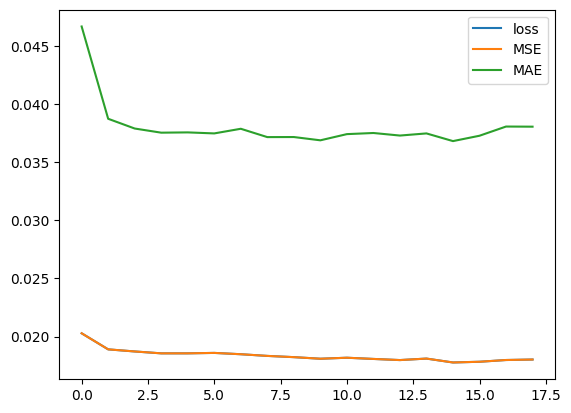

In [421]:
pyplot.plot(history.history['loss'], label='loss')
pyplot.plot(history.history['mean_squared_error'], label='MSE')
pyplot.plot(history.history['mean_absolute_error'], label="MAE")
pyplot.legend(loc="upper right")
pyplot.show()

#### **7.5. EVALUACIÓN**

Veamos el rendimiento del modelo sobre el conjunto de test.

Ya sabemos que el problema presenta desbalanceo de clases. Como en el caso anterior (árboles) vamos a analizar las métricas de precision, recall, F1-score y accuracy.

In [422]:
y_pred_prob = model.predict(X_test)

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Nótese que nuestro modelo devuelve la probabilidad de injury, siendo 0 = NO LESIÓN Y 1 = LESIÓN. 

Una primera aproximación, por defecto, es estimar que si la probabilidad que predice el modelo es > de 0.5 entonces habrá lesión. Veamos los resultados de esta forma:

In [423]:
y_pred = (y_pred_prob > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[3321    0]
 [  67    1]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3321
           1       1.00      0.01      0.03        68

    accuracy                           0.98      3389
   macro avg       0.99      0.51      0.51      3389
weighted avg       0.98      0.98      0.97      3389



Podemos probar a bajar el umbral de decisión (treshold) y ver si el resultado mejora.

In [429]:
for t in [0.5, 0.2, 0.1, 0.05, 0.025, 0.01, 0.001]:
    y_pred = (y_pred_prob > t).astype(int)
    print("\n------------------------------------")
    print("------------------------------------")
    print("------------------------------------")
    print(f"\nThreshold: {t}")
    print("\n-----------------MATRIZ DE CONFUSIÓN----------")
    print(confusion_matrix(y_test, y_pred))
    print("\n-----------------MÉTRICAS DEL MODELO----------")
    print(classification_report(y_test, y_pred))


------------------------------------
------------------------------------
------------------------------------

Threshold: 0.5

-----------------MATRIZ DE CONFUSIÓN----------
[[3321    0]
 [  67    1]]

-----------------MÉTRICAS DEL MODELO----------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3321
           1       1.00      0.01      0.03        68

    accuracy                           0.98      3389
   macro avg       0.99      0.51      0.51      3389
weighted avg       0.98      0.98      0.97      3389


------------------------------------
------------------------------------
------------------------------------

Threshold: 0.2

-----------------MATRIZ DE CONFUSIÓN----------
[[3313    8]
 [  65    3]]

-----------------MÉTRICAS DEL MODELO----------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3321
           1       0.27      0.04      0.08        68

    acc

Vemos que el umbral de 0.5 es altamente restrictivo, y apenas sirve para predecir lesiones. 

Reducir este umbral nos permite aumentar el recall de la clase minoritaria (lesiones), lo cual es crítico en este problema: Es preferible detectar una posible lesión aunque se incrementen los falsos positivos. Deberíamos buscar un equilibrio. Es decir, fijar un umbral en el que nos compense (económicamente, deportivamente, etc.) asumir el riesgo de fallar en la predicción, en favor de la salud del jugador.

A la vista de los resultados, podríamos admitir que un umbral razonable sería una probabilidad de entre 0.05 y 0.025:

- Treshold = 0.05 -> 16 lesiones predichas correctamente vs 128 falsos positivos, i.e, falsas alarmas de lesión. En cuanto a la clase mayoritaria, predice satisfactoriamente el 96% de los casos positivos. Con este umbral, el rendimiento del modelo ya es considerablemente mejor que el de los árboles. Muy buen equilibrio. Lo comentaremos en la siguiente sección.

- Treshold = 0.025 -> 38 lesiones predichas correctamente vs 405 falsos positivos, i.e, falsas alarmas de lesión. Tener 648 avisos de lesión que no lleguen a serlo, entre aprox 3400 datos totales en el conjunto de test parece razonable. Estaríamos hablando de que en aproximadamente un 19% (650/3400) de los partidos un jugador no habría jugado por riesgo de lesión, cuando si realmente hubiese jugado, no se hubiera lesionado. Habría que analizar a nivel económico si compensa ese 19%, y realizar un estudio mucho más exhaustivo. Pero, a simple vista, parece razonable.

Por último, vemos que:

- Threshold = 0.01 -> 63 lesiones predichas correctamente (de 68 totales) vs 2153 falsas alarmas. Este umbral ya es inviable, y falla más que acierta en la clase mayoritaria.


#### **7.6. GUARDADO DEL MODELO**

Antes de concluir la parte de redes neuronales, guardamos el modelo entrenado, como se nos pide en el enunciado del proyecto. 

Al igual que antes, esto nos permite almacenar el modelo entrenado para su posterior reutilización, sin necesidad de reentrenamiento. Esto es especialmente relevante en el caso de las redes neuronales, puesto que en función de los hiperparámetros y de la capacidad computacional disponible, su entrenamiento puede requerir bastante tiempo.

In [434]:
# LIBRERÍA

from keras.models import load_model

# GUARDAR MODELO

model.save("modelo_red_neuronal.keras")

# CARGAR MODELOS

loaded_model_red = load_model("modelo_red_neuronal.keras")

# USAR MODELO CARGADOS PARA PREDICCIÓN

y_pred_red_loaded_prob = loaded_model_red.predict(X_test)
y_pred_red = (y_pred_red_loaded_prob> 0.05).astype(int)

matriz_red_loaded = confusion_matrix(y_test, y_pred_red)
report_red_loaded = classification_report(y_test, y_pred_red)


print("\n--------------RESULTADOS MODELO RED (CARGADO)-------------------\n")
print(matriz_red_loaded)
print("\n----------------------------------------------------------------\n")
print(report_red_loaded)



106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--------------RESULTADOS MODELO RED (CARGADO)-------------------

[[3193  128]
 [  52   16]]

----------------------------------------------------------------

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3321
           1       0.11      0.24      0.15        68

    accuracy                           0.95      3389
   macro avg       0.55      0.60      0.56      3389
weighted avg       0.97      0.95      0.96      3389



Efectivamente, vemos que el modelo se ha cargado correctamente, Obtenemos exactamente los mismos resutlados que antes.

### **8. COMPARATIVA ENTRE MODELOS - CONCLUSIÓN**

**NUESTRO CRITERIO DE COMPARACIÓN**

Podemos establecer como criterio para comparar ambos modelos (árboles y redes) el recall de la clase minoritaria (1). Es decir, el ratio de lesiones correctamente predichas. Recordemos las matrices de confusión obtenidas con árboles, y comparémoslas con las que tenemos justo arriba, para redes.

In [431]:
# ÁRBOL - MODELO ORIGINAL
print("ÁRBOL - MODELO ORIGINAL")
print(matriz_tree)

print("\n-----------------------\n")

# ÁRBOL - MODELO MEJORADO (SMOTE)
print("ÁRBOL - MODELO ORIGINAL")
print(matriz_tree_smote)

ÁRBOL - MODELO ORIGINAL
[[3191  130]
 [  62    6]]

-----------------------

ÁRBOL - MODELO ORIGINAL
[[3220  101]
 [  59    9]]


In [432]:
'''
RED NEURONAL - Threshold: 0.05

[[3193  128]
 [  52   16]]
 
 -----------------------

RED NEURONAL - Threshold: 0.025
[[2673  648]
 [  30   38]]
'''

'\nRED NEURONAL - Threshold: 0.05\n\n[[3193  128]\n [  52   16]]\n\n -----------------------\n\nRED NEURONAL - Threshold: 0.025\n[[2673  648]\n [  30   38]]\n'

Recopilemos igualmente los valores del recall de la clase minoritaria. Es decir, el ratio de lesiones correcamente predichas (cuantas lesiones predijo correctamente de entre todas las que se produjeron):

            | MODELO | Recall (clase 1) |

- ÁRBOL ORIGINAL | 0.09 (6/68)
- ÁRBOL SMOTE | 0.13 (9/68)
- RED (t = 0.05) | 0.24 (16/68)
- RED (t = 0.025) | 0.56 (38/648)


Para la red neuronal, podemos tomar como referencia el umbral de 0.05, que parece bastante razonable pues se equivoca "poco" en la clase mayoritaria. El umbral de 0.025 quizá falla demasiado. Podría ser interesante probar otros valores intermedios. Pero, como elección final, tomemos el caso de 0.05.

Para los árboles, tomamos como referencia el segundo modelo en el que intentamos solucionar el desbalanceo de clases con SMOTE, pues mejoró el rendimiento del modelo.

A simple vista, parece que la red neuronal tiene un desempeño mucho mejor que los árboles. Esto es coherente con lo que estudiabamos en clase: Los árboles tienen una interpretación más sencilla, pero las redes neuronales tienen mayor capacidad de cómputo/adaptabilidad a problemas más complejos.

Aunque el modelo de la red admite aún muchas mejoras (ajuste de hiperparámetros, estructura de red con diferente número de capas y neuronas, empleo de pesos para equilibrar el desbalanceo de clases, etc.), concluimos que es el más que ha tenido un desempeño más satisfactorio. 

En concreto, tomando el treshold de t=0.05, el modelo predice correctamente el 96% de la clase positiva (en el 96% de los casos que dijo que no habría lesión, efectivamente no la hubo), y el 25% de la clase negativa (es decir, en el 2%% de los casos que dijo que sí habría lesión, efectivamente la hubo). Aunque está aún lejos de ser perfecto, es el modelo más equilibrado con mucha diferencia.

**CONCLUSIÓN: NOS QUEDAMOS CON LA RED NEURONAL COMO MODELO CON MEJOR PERFORMANCE PARA EL PROBLEMA PROPUESTO.**

Sería interesante aplicar algunas de las mejoras comentadas al modelo de la red y analizar si el rendimiento puede mejorar aún más. Aún así, los resultados obtenidos son coherentes con el objetivo del problema y podrían tomarse como estudio inicial (punto de partida) para una implementación práctica en entornos deportivos. 

Por otro lado, he pensado sí estos modelos podrían ser aplicables a algún equipo de Liga Endesa, o a la liga en su conjunto. Cabe mencionar que necesitamos un dataset suficientemente grande como para obtener resultados consistentes, y dudo que estos datos existan, o si existen, que estén disponibles como los de NBA.

---

Sin más comentarios, damos por finalizado el ejercicio. Y con él, el TFA de la asignatura.

---
---
---
---
---



## **FINAL DE LA TAREA 2**

---
---
---
---
---

---
---
---
---
---

## **BIBLIOGRAFÍA**

Para la elaboración de la presente entrega se han utilizado las siguientes **fuentes**:

[1] - Jaime Mallo Antelo. Machine Learning I. Apuntes y sesiones de la asignatura. Máster en Basket Data Analytics y Sports Management. UNAM. SBL Education. Curso 2025/2026.

Disponible en el campus virtual: https://aulavirtual.unam.es/course/view.php?id=131. Última consulta: 20/04/2026.


[2] - James, Gareth & Witten, Daniela & Hastie, Trevor & Tibshirani, Robert & Taylor, Jonathan. (2023). An Introduction to Statistical Learning: with Applications in Python. 10.1007/978-3-031-38747-0. 

Disponible para descargar de manera gratuita en: https://www.statlearning.com/


[3] - K. Lee, D. Yoo, W. Jeong y S. Han. «SIMPLE-NN: An efficient package for training and executing neural-network interatomic potentials». En: Computer Physics Communications. Vol. 242. págs. 95-103. 2019. doi: https://doi.org/10.1016/j.cpc.2019.04.014. Última consulta: 06/04/2026.

(Paper utilizado en mi TFG de Física el curso pasado. Lo consulté para ampliar/refrescar alguna información. No fue imprescindible para la entrega)

---

Adicionalmente, comentar que se han utilizado de manera puntual herramientas de IA generativa, para entender mejor ciertas partes del código de los ejemplos presentados en las sesiones de la asignatura. En concreto:

[4] - OpenAI. (2026). ChatGPT [Large language model]. https://chat.openai.com/chat

Decidí preguntar a CHAT GPT, pues al ejecutar el ejemplo de clase 'C4_Ajuste_Hiperparametros_Redes_Neuronales_Keras.ipynb' me saltaba un error en cierta parte del código, y no podía correrlo completamente. Gracias a su ayuda, pude ver que no era un error de código, sino de la configuración archivos de mi ordenador/One Drive, y pude solucionarlo. 

Considero que estas tecnologías son una gran herramienta, pero siempre que sean utilizada con coherencia En ningún caso puede sustituir al pensamiento crítico ni al conocimiento experto. No podemos delegarle todo el trabajo, porque no aprenderíamos nada, pero podemos valernos de ella para facilitar/reforzar nuestro propio aprendizaje.



---
---
---
---
---

## **COMENTARIOS FINALES - CONCLUSIÓN SOBRE MLI (ASIGNATURA & TFA)**


En general, la asignatura me ha resultado de gran interés y he disfrutado mucho de ella. 

Por mi formación académica (Matemáticas - Física), el propio contenido teórico me ha llama enormemente la atención. El curso pasado utilicé redes neuronales en la elaboración de mi TFG de Física, para simular el comportamiento de un material en condiciones de presión y temperatura inaccesibles en un laboratorio. Por ello, volver a utilizar redes neuronales, pero ahora con un enfoque totalmente diferente, me ha resultado muy satisfactorio. 

Considero que las herramientas aportadas al alumno son de gran calidad. Tanto los datasets y ejemplos vistos en clase, como el proyecto final propuesto. Debido a mi background, me resultaría interesante profundizar un poco más en los propios modelos desde el punto de vista matemático, comparar exhaustivamente los modelos a nivel computacional/numérico, etc. Sin embargo, esto es una inclinación personal, y no considero que esto fuera beneficioso en general para la asignatura, pues quizá el resto de los alumnos no lo consideren tan fundamental/interesante. 

La asignatura es un gran punto de partida para adentrarse en Machine Learning, dando una visión global muy buena de muchos aspectos, y permitiendo al alumno profundizar más en aquello que le interese. De este modo, no tengo ninguna posible mejora que comentar. ¡Espero que mi feedback resulte beneficioso!

En conclusión, estoy muy satisfecho con la asignatura de MLI y con el trabajo en su conjunto. Me ha resultado muy interesante, y me ha motivado para indagar más en este campo.

---
---
---
---
---

## **NOTA FINAL AL LECTOR**

Gracias por tu atención y dedicación en la corrección.

Disculpa por la extensión del notebook. Sé que son muchas líneas de código (y de texto), pero he querido realizar el trabajo lo más detallado y explicado posible.

Si se te ocurre cualquier posible mejora o corrección en cualquiera de los ejercicios, tanto de contenido como de formato, estaré encantado de recibir tu feedback. Ya sea a través del campus virtual, o del correo electrónico, lo que consideres. Por si acaso, te pongo aquí mi correo:

pablogv.data.analysis@gmail.com


---


Por último, comentarte que nos queda pendiente la revisión de la tarea por videollamada. Te he preguntado sobre ello por correo electrónico/campus virtual, para fijar la fecha lo antes posible y dejarlo solucionado. Ya me dices cuando puedas.

¡Muchas gracias de nuevo!

Un abrazo.

Pablo Gómez Villamayor.



## **FINAL DEL TRABAJO**